In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('covid19_tweets.csv')
df['date'] = pd.to_datetime(df['date']).dt.date
print(df.head())
print(df.info())

         user_name         user_location  \
0           ᏉᎥ☻լꂅϮ            astroworld   
1    Tom Basile 🇺🇸          New York, NY   
2  Time4fisticuffs      Pewee Valley, KY   
3      ethel mertz  Stuck in the Middle    
4         DIPR-J&K     Jammu and Kashmir   

                                    user_description         user_created  \
0  wednesday addams as a disney princess keepin i...  2017-05-26 05:46:42   
1  Husband, Father, Columnist & Commentator. Auth...  2009-04-16 20:06:23   
2  #Christian #Catholic #Conservative #Reagan #Re...  2009-02-28 18:57:41   
3  #Browns #Indians #ClevelandProud #[]_[] #Cavs ...  2019-03-07 01:45:06   
4  🖊️Official Twitter handle of Department of Inf...  2017-02-12 06:45:15   

   user_followers  user_friends  user_favourites  user_verified        date  \
0             624           950            18775          False  2020-07-25   
1            2253          1677               24           True  2020-07-25   
2            9275          9525    

In [3]:
# count tweets per day
daily_counts = df.groupby('date').size().reset_index(name='tweet_count')

# cumulative tweets for R(t)
daily_counts['cumulative'] = daily_counts['tweet_count'].cumsum()

In [4]:
total_users = 1000000  # arbitrary estimate of population interested in COVID-19 tweets
daily_counts['S'] = total_users - daily_counts['cumulative']
daily_counts['I'] = daily_counts['tweet_count']
daily_counts['R'] = daily_counts['cumulative']

print(daily_counts.head())

         date  tweet_count  cumulative       S      I      R
0  2020-07-24          295         295  999705    295    295
1  2020-07-25        16881       17176  982824  16881  17176
2  2020-07-26         7500       24676  975324   7500  24676
3  2020-07-27         7500       32176  967824   7500  32176
4  2020-07-28         7500       39676  960324   7500  39676


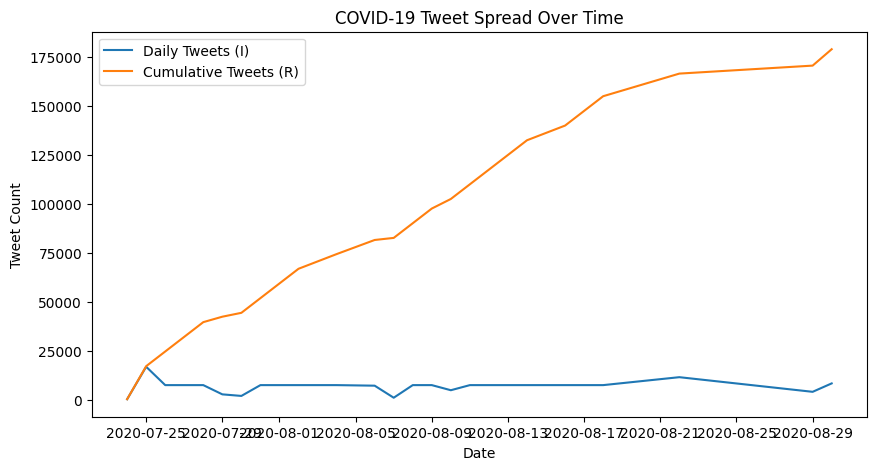

In [5]:
plt.figure(figsize=(10,5))
plt.plot(daily_counts['date'], daily_counts['I'], label='Daily Tweets (I)')
plt.plot(daily_counts['date'], daily_counts['R'], label='Cumulative Tweets (R)')
plt.xlabel('Date')
plt.ylabel('Tweet Count')
plt.title('COVID-19 Tweet Spread Over Time')
plt.legend()
plt.show()

In [6]:
print(daily_counts['I'].describe())

count       26.000000
mean      6888.769231
std       3226.379783
min        295.000000
25%       7285.500000
50%       7500.000000
75%       7500.000000
max      16881.000000
Name: I, dtype: float64


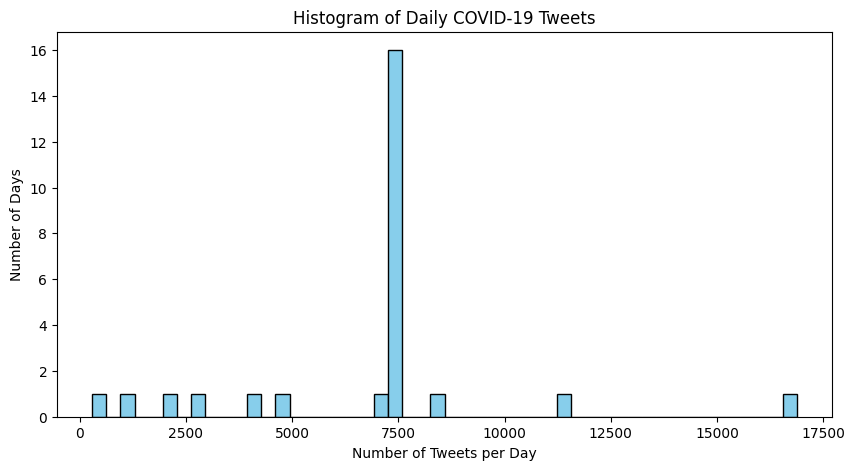

In [7]:
plt.figure(figsize=(10,5))
plt.hist(daily_counts['I'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Number of Tweets per Day')
plt.ylabel('Number of Days')
plt.title('Histogram of Daily COVID-19 Tweets')
plt.show()


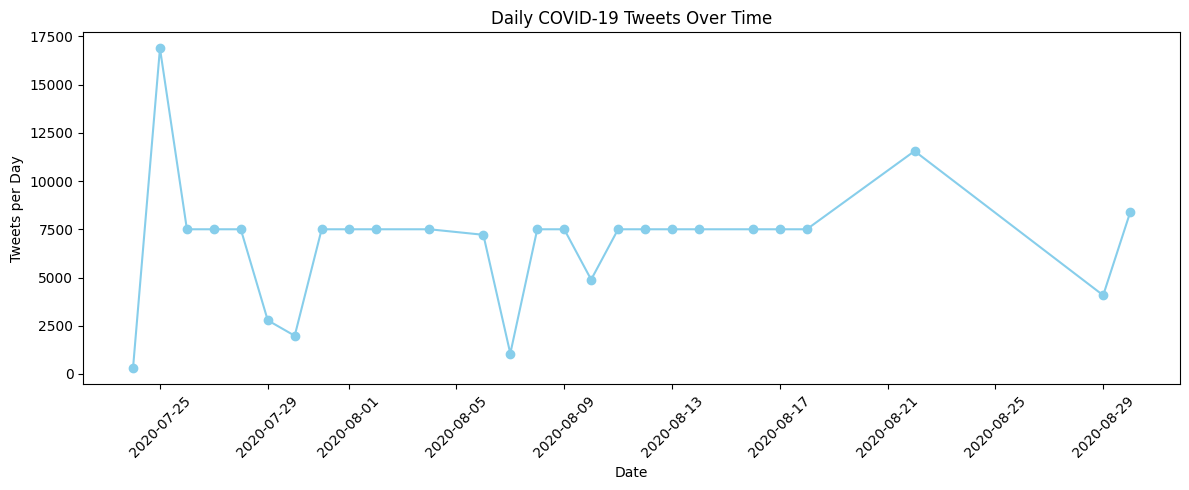

In [8]:
plt.figure(figsize=(12,5))
plt.plot(daily_counts['date'], daily_counts['I'], marker='o', linestyle='-', color='skyblue')
plt.xlabel('Date')
plt.ylabel('Tweets per Day')
plt.title('Daily COVID-19 Tweets Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()